# NASA randomized and recommissioned battery dataset

An accelerated Life Testing Dataset for Lithium-Ion Batteries with Constant and Variable Loading Conditions:

The dataset repository is organized into three main folders, each containing one group of life cycled battery packs. 
Within each folder individual battery packs own their dedicated csv file for continuous data logging, which are named with their respective battery pack number.

The folders are named: 

- regular_alt_batteries: Containing one csv file for each battery pack cycled at the same load level or load range throughout lifetime
- recommissioned_batteries: Containing one csv file for each battery pack cycled at different load levels at varying life stages
- second_life_batteries: Containing one csv file for each second life battery pack cycled at constant current througout the second life 

The columns in each csv file contain the following data with the provided units: 

The following columns contain data throughout the cycling process: 

- start time: [mm:dd:yyyy hh:mm:ss] (start time of each cycle day for each battery pack, in most cases approximately 24h)
- relative time: [s] (the relative time is continuous from the beginning of the entire life cycle to the failure of each battery pack)
- mode: -1 = discharge, 0 = rest, 1 = charge
- voltage charger: [V] (continuous battery pack voltage measurement right after the connection of the battery pack to the charger board)
- temperature battery: [C] (continuous temperature measurement on the battery cell electrode surface)

Those columns only contain data when the respective battery is connected to the load board and performing a discharge mission

- voltage load: [V] (battery pack voltage measured on the load board)
- current load: [A] (discharge current measured on the load board using current sense resistors)
- temperature mosfet: [C] (temperature on the load board mosfets, measured for safety purposes)
- temperature resistor: [C] (temperature on the load board current sense resistor, measured for safety purposes)
- mission type: 0 = reference discharge (constant current at 2.5A), 1 = regular mission

Please cite this dataset using:

```
@misc{2023_alt_dataset_fricke_et_al,
	Author = {Kajetan Fricke and Renato G. Nascimento and Felipe A. C. Viana},
	Doi = {},
	Howpublished = {},
	Month = {July},
	Publisher = {nasa-data@lists.arc.nasa.gov},
	Title = {An accelerated Life Testing Dataset for Lithium-Ion Batteries with Constant and Variable Loading Conditions},
	Url = {},
	Version = {0.0.1},
	Year = {2023}}
```

The corresponding reference entry should look like: 
An accelerated Life Testing Dataset for Lithium-Ion Batteries with Constant and Variable Loading Conditions, v0.0.1, 

### Publications

The following publications out of the PML-UCF research group used/referred to this repository:
- K. Fricke, R. G. Nascimento, M. Corbetta, C. S. Kulkarni, F. A. C. Viana, "[Prognosis of Li-ion Batteries Under Large Load Variations Using Hybrid Physics-Informed Neural Networks]"
- K. Fricke, R. G. Nascimento, M. Corbetta, C. S. Kulkarni, F. A. C. Viana, "[An accelerated Life Testing Dataset for Lithium-Ion Batteries with Constant and Variable Loading Conditions]"


## Regular accelerated life test (regular alt batteries folder):

This folder contains the data files from battery packs subject to constant and variable loading conditions, 
where the current range of the latter remains the same throughout the battery life.

The assigned battery packs in this folder are numbered as
follows:

– Constant current:
Those battery packs were subjected to the same load level during discharge missions over their respective life time.

The here provided averaged current levels are approximated, and might vary slightly:

* 9.30A: Battery pack 0.1 and 1.1
* 12.9A: Battery pack 3.1 and 2.2
* 14.3A: Battery pack 2.3 and 5.2
* 16.0A: Battery pack 0.0 and 1.0
* 19.0A: Battery pack 2.0, 3.0 and 2.1

– Variable current:

Those battery packs are subjected to variable current within a discharge cycle.
The current level segments are kept constant for either 40, 60 or 80 seconds before switching to another level.
Both, the amplitude and length of each current level segments was randomly selected to create a pool of different random loading discharge missions.

The here provided averaged current levels are approximated, and might vary slightly:

* 14.3A average (12.9A - 16A range): Battery pack 4.1 and 5.1
* 17.0A average (16A - 19A range): Battery pack 4.0 and 5.0


## Recommissioned batteries (recommissioned batteries folder):

This folder contains the data files from battery packs where the constant loading conditions were changed throughout the battery life. 
The assigned battery packs in this folder are numbered as follows:

– Two life stages:
The following batteries were subjected to constant current levels at the first provided amplitudes until reaching an capacity level of approximately 2.2Ah,
and then switched to the second current level until reaching end of life

The here provided averaged current levels are approximated, and might vary slightly:

* 16A, 14.3A: Battery pack 3.2
* 14.3A, 16A: Battery pack 5.3
* 16A, 12.9A: Battery pack 0.2 and 3.3
* 16A, 9.30A: Battery pack 1.2 and 2.4

– Three life stages:
Those batteries were subjected to current level switches at approximately 2.2Ah and 2.0Ah of capacity.
The here provided averaged current levels are approximated, and might vary slightly:

* 16A, 14.3A, 7.5A: Battery pack 0.3
* 16A, 7.5A, 14.3A: Battery pack 2.5


## Second life batteries (second life batteries folder):

This folder contains the data files from battery packs that consist of battery cells survived from previously cycled battery packs. 
The assigned battery packs in this folder are numbered as follows:

– 2nd life battery packs:
The following batteries were subjected to constant current levels at the first provided amplitudes until reaching end of life (EOL).
Survivor cells were then reused and subjected to the second provided current level until reaching EOL

The here provided averaged current levels are approximated, and might vary slightly:

* 16.0A, 9.3A: Battery pack 1.3 (First life battery packs: 0.0 & 1.1)
* 14.3A, 7.5A: Battery pack 3.6 (First life battery packs: 2.3 & 5.2)
* 12.9A, 5.0A: Battery pack 5.4 (First life battery packs: 2.2 & 3.1)

# Machine Learning

## Train-Test-Split

In [1]:
import pandas as pd
import numpy as np

#define datasets
C_Rate_Hist_Features = ['sec_C_rate_0_0.5', 'sec_C_rate_0.5_1', 'sec_C_rate_1_2', 'sec_C_rate_2_3', 'sec_C_rate_3_4',\
                  'sec_C_rate_4_5', 'sec_C_rate_5_6', 'sec_C_rate_6_7', 'sec_C_rate_gt_7']

Temp_Hist_Features = ['sec_T_15_30','sec_T_30_45','sec_T_45_60','sec_T_60_80','sec_T_gt_80']

SOH_Features = ['SOH', 'SOH(-30EFC)', 'SOH(-60EFC)', 'SOH(-90EFC)', 'SOH(-120EFC)']

#define all battery labels
batt_labels = ['battery00','battery01','battery10','battery11','battery20','battery21','battery22',\
              'battery23','battery30','battery31','battery40','battery41','battery50','battery51','battery52',\
              'battery02','battery03','battery12','battery24','battery25','battery32','battery33','battery53']

complete_df = pd.read_csv("data_complete.csv")

test_labels = ['battery00','battery21','battery51','battery12','battery33']
train_labels = list(set(batt_labels) - set(test_labels))

train_df = pd.DataFrame([])
test_df = pd.DataFrame([])

for label in train_labels:
    train_df = pd.concat([train_df,complete_df[complete_df['batt_label']==label]],axis=0)

for label in test_labels:
    test_df = pd.concat([test_df,complete_df[complete_df['batt_label']==label]],axis=0)

complete_df.head(3)

,batt_label,isRefCycle,time_sec,EFC,E_cum_Wh,Q_norm_at_3.9_V,Q_norm_at_3.8_V,Q_norm_at_3.7_V,Q_norm_at_3.6_V,T_cum_avg,...,integral_low_temp_high_discharge,integral_discharge_squared,integral_discharge_squared_T,R_mOhm,SOH,SOH(-30EFC),SOH(-60EFC),SOH(-90EFC),SOH(-120EFC),RUL_EFC
0,battery00,True,7424.475,1.001191,17.149865,0.035325,0.189894,0.278888,0.400940,26.569209,...,0.0,3708.145701,5.903383e+04,218.253968,100.119145,100.0,100.0,100.0,100.0,150.411108
1,battery00,False,12219.679,1.995107,32.833935,0.038305,0.190357,0.282313,0.403624,32.363611,...,0.0,27524.505551,1.368496e+06,48.257469,99.901151,100.0,100.0,100.0,100.0,149.417193
2,battery00,False,17025.679,2.992049,48.630552,0.041295,0.190822,0.285749,0.406316,35.243437,...,0.0,51402.298334,2.738069e+06,48.681734,99.682492,100.0,100.0,100.0,100.0,148.420251


In [2]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Aufteilung in 4 Gruppen, so dass in jeder Gruppe ungefähr gleiche Verteilung von
# Strömen und regular/recomissioned test
batt_groups = [['battery01','battery22','battery10','battery50','battery32','battery03'],
               ['battery11','battery23','battery20','battery41','battery53','battery24'],
               ['battery31','battery52','battery30','battery40','battery02','battery25'],
               ['battery00','battery21','battery51','battery12','battery33']]
               

all_mae = {}

def split_test_train(data,train_labels,test_labels):
    '''
    Macht Test-Train-Split anhand der übergebenen Train- und Test-Labels
    '''
    train_df = pd.DataFrame([])
    test_df = pd.DataFrame([])

    for label in train_labels:
        train_df = pd.concat([train_df,data[data['batt_label']==label]],axis=0)

    for label in test_labels:
        test_df = pd.concat([test_df,data[data['batt_label']==label]],axis=0)

    return train_df, test_df

def train_gradient_boost(data, train_labels, test_labels, target, feature_set):
    '''
    Trainiert Gradient Boost Modelle für 10, 30, 100, 300 und 1000 Estimators
    für übergebene Train- und Test Labels, Target und Features
    '''
    train_df, test_df = split_test_train(data,train_labels,test_labels)
    #n_est_list = [10,30,100,300,1000]
    #learn_rate_list = [0.15,0.1,0.05,0.02,0.01]
    n_est_list = [10,30,100,300]
    learn_rate_list = [0.15,0.1,0.05,0.02]
    le = len(n_est_list)
    models = le*[None]
    maes = le * [0.0]
    importance = np.array(len(feature_set)*[0.0])

    y_train = train_df[target]
    y_test = test_df[target]
    
    if len(feature_set) == 1:
        X_train = np.array(train_df[feature_set[0]]).reshape(-1,1)
        X_test = np.array(test_df[feature_set[0]]).reshape(-1,1)
    else:
        X_train = train_df[feature_set]
        X_test = test_df[feature_set]

    for i,n_estimators in enumerate(n_est_list):
        gbrt = GradientBoostingRegressor(max_depth=2, n_estimators=n_estimators,
                        learning_rate=learn_rate_list[i], random_state=42)
        gbrt.fit(X_train, y_train)
        y_test_predict = gbrt.predict(X_test)
        test_mae = mean_absolute_error(y_test,y_test_predict)
        models[i] = gbrt
        maes[i] = test_mae
        #print(f"MAE bei {n_estimators} estimators: {maes[i]}")

    # printe feature importance für modell mit bestem MAE
    best_idx = np.argmin(maes)
    best_model = models[best_idx]
    #print(f"Anzahl Estimators mit bestem MAE: {n_est_list[best_idx]}")

    if len(feature_set) != 1:   
        importance = best_model.feature_importances_
        
    return maes, importance, models

def do_fold_cross_valid(data, target, feature_set):
    '''
    Trainiert Gradient Boost Modelle und macht eine Four-Fold-Cross Validation für
    übergebenes Target und Feature Set
    '''
    #sum_maes = np.array(5 * [0.0])
    sum_maes = np.array(4 * [0.0])
    len_importance = len(feature_set)
    sum_importance = np.array(len_importance*[0.0])
    size = len(batt_groups)

    for i in range(size):
        train_labels = list(set(batt_labels) - set(batt_groups[i]))
        test_labels = batt_groups[i]
        mae, importance, dummy = train_gradient_boost(data, train_labels, test_labels, target, feature_set)
        print(f"MAEs set nr. {i}: {mae}")
        sum_maes += np.array(mae)
        sum_importance += np.array(importance)

    mean_maes = sum_maes / size
    mean_importance = sum_importance / size

    # print mean feature importance averaged over all training sets
    if len_importance != 1:   
        feat_imp = pd.DataFrame({
            "Feature": feature_set,
            "Importance": mean_importance
        })
        
        feat_imp = feat_imp.sort_values(
            by="Importance",
            ascending=False
        )

        print("************Mean Featue Importances averaged over all training sets:**************")
        print(feat_imp)

    
    print("********************Mean MAEs averaged over all test sets:***********************")
    print(f"Mean MAEs: {mean_maes}")
    return mean_maes

def append_mae(name, data, target, features):
    '''
    Trainiert Gradient Boost Modelle, macht Four-Fold-Cross Validation und speichert
    Ergebnisse in Dictionary
    '''
    mean_maes = do_fold_cross_valid(data, target, features)
    all_mae[name] = {}
    all_mae[name]["MAE @ 10 Estimators"] = mean_maes[0]
    all_mae[name]["MAE @ 30 Estimators"] = mean_maes[1]
    all_mae[name]["MAE @ 100 Estimators"] = mean_maes[2]
    all_mae[name]["MAE @ 300 Estimators"] = mean_maes[3]
    #all_mae[name]["MAE @ 1000 Estimators"] = mean_maes[4]

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

def plot_predictions(model=None, data=None, feature=None, target=None, title=None, legend=False, gradientBoost = True):
    ma = data[feature].max()
    x1 = np.linspace(0, ma*1.1, 500)
    fig, axes = plt.subplots(ncols=1, figsize=(10, 4), sharey=True)
    if model != None:
        y_pred = model.predict(x1.reshape(-1,1))
        plt.plot(x1, y_pred, "r-", linewidth=2, label='model')
        if gradientBoost:
            plt.title(f"{title} learning_rate={model.learning_rate}, n_estimators={model.n_estimators_}")
        else:
            plt.title(f"{title} intercept={model.intercept_}, coef={model.coef_}")

    sns.scatterplot(data=data, x=feature, y=target, hue='batt_label', legend=legend)

    plt.xlabel(feature)
    plt.ylabel(target, rotation=0)
    plt.show()

    new_dir = Path('diagrams')
    new_dir.mkdir(exist_ok=True)
    
    filename = new_dir / f"{title} {target} vs {feature}.png"
    fig.savefig(filename)

## Komplettes Feature Set

In [4]:
drop_features = ['batt_label','isRefCycle','RUL_EFC'] + SOH_Features
all_features = complete_df.columns
train_features = list(set(all_features) - set(drop_features))
append_mae("Complete Feature Set", complete_df, "SOH", train_features)

MAEs set nr. 0: [1.4701258628267424, 1.2377886483203042, 1.3076322154603874, 1.2819591243481838]
MAEs set nr. 1: [1.646737205551681, 1.0183801908801642, 0.9878276138237571, 0.9939431876627682]
MAEs set nr. 2: [1.7395374343506247, 1.1070969651464513, 1.0364720197762942, 1.0782198433912684]
MAEs set nr. 3: [1.9273339012473232, 1.196948916909754, 0.9733639479839274, 0.9415914567823362]
************Mean Featue Importances averaged over all training sets:**************
                              Feature  Importance
34   integral_low_volt_high_discharge    0.396000
35       integral_discharge_squared_T    0.371692
9                     Q_norm_at_3.6_V    0.122703
1                         sec_T_30_45    0.031840
41         integral_discharge_squared    0.016734
42                 sec_at_low_voltage    0.010147
15  integral_high_temp_high_discharge    0.006872
22                     sec_C_rate_6_7    0.005405
6                       sec_T_over_40    0.004827
37                          T_c

## EFC Feature

In [5]:
train_features = ['EFC']
append_mae("EFC Feature", complete_df, "SOH", train_features)

MAEs set nr. 0: [2.6940387593085613, 2.4492227450368325, 2.438008499066506, 2.432021349001606]
MAEs set nr. 1: [2.794665815444033, 2.268342868781171, 2.1895444687876413, 2.186190611048608]
MAEs set nr. 2: [2.204504594887608, 1.838972274387519, 1.760490161144582, 1.7530462854123798]
MAEs set nr. 3: [2.426951517644143, 1.875121846029262, 1.7660942390476502, 1.7555239510732652]
********************Mean MAEs averaged over all test sets:***********************
Mean MAEs: [2.53004017 2.10791493 2.03853434 2.03169555]


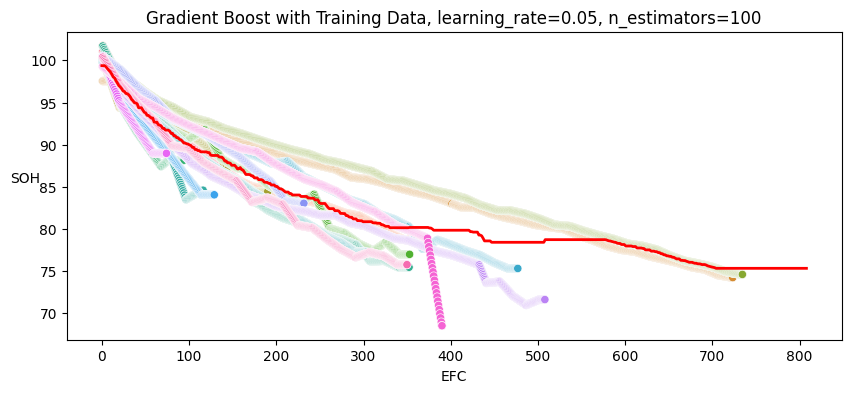

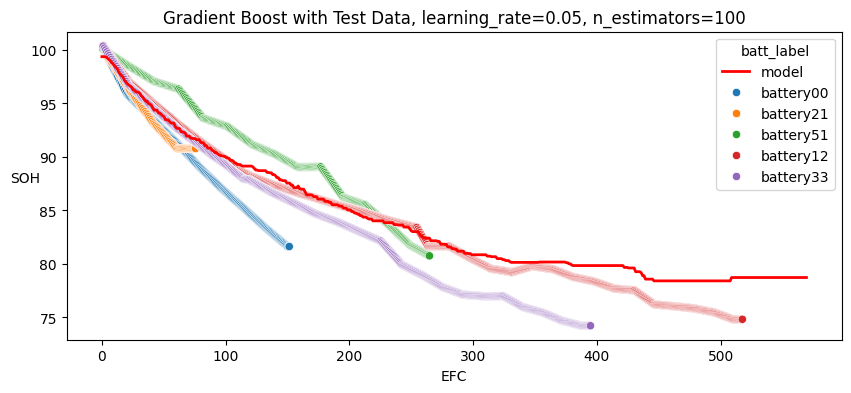

In [6]:
best_model = GradientBoostingRegressor(max_depth=2, n_estimators=100,
                        learning_rate=0.05, random_state=42)

X_train = np.array(train_df['EFC']).reshape(-1,1)
y_train = train_df['SOH']

best_model.fit(X_train, y_train)
plot_predictions(best_model, train_df, 'EFC', "SOH", "Gradient Boost with Training Data,")
plot_predictions(best_model, test_df, 'EFC', "SOH", "Gradient Boost with Test Data,", legend=True)

In [7]:
train_features = ['EFC', 'C_rate_cum_avg']
append_mae("EFC and C rate average Features", complete_df, "SOH", train_features)

MAEs set nr. 0: [2.618694149651234, 2.1908914245021305, 2.0811410443512814, 2.0706282106545926]
MAEs set nr. 1: [2.572301408147611, 1.88730287271874, 1.5839037764340091, 1.5073873504942092]
MAEs set nr. 2: [2.13937680841122, 1.61515495011442, 1.3554980916321864, 1.3364650106390985]
MAEs set nr. 3: [2.2106979870717915, 1.4869702304045322, 1.2360370433756365, 1.3048858786374045]
************Mean Featue Importances averaged over all training sets:**************
          Feature  Importance
0             EFC     0.90002
1  C_rate_cum_avg     0.09998
********************Mean MAEs averaged over all test sets:***********************
Mean MAEs: [2.38526759 1.79507987 1.56414499 1.55484161]


## Q_norm Features

### Nur Q_norm_at_3.6V Feature

In [8]:
train_features = ['Q_norm_at_3.6_V']
append_mae("Q_norm_at_3.6_V Feature Set", complete_df, "SOH", train_features)

MAEs set nr. 0: [1.5916052251276378, 1.1283476592286583, 1.125036859119808, 1.1255811265031608]
MAEs set nr. 1: [1.6548925609266276, 1.0916215189451108, 1.0286139627647635, 1.0187684447234504]
MAEs set nr. 2: [1.8818573664790508, 1.371540163107479, 1.322610780410637, 1.318254507372681]
MAEs set nr. 3: [1.9406965990171938, 1.3023458407021877, 1.1761128323582495, 1.1648020377410266]
********************Mean MAEs averaged over all test sets:***********************
Mean MAEs: [1.76726294 1.2234638  1.16309361 1.15685153]


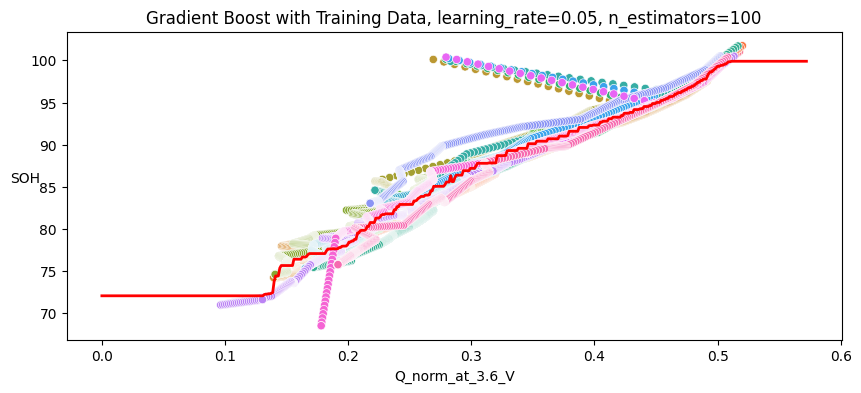

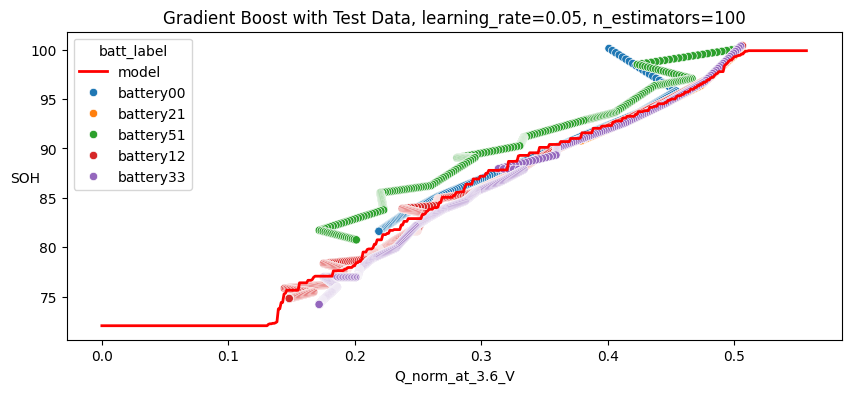

In [9]:
best_model = GradientBoostingRegressor(max_depth=2, n_estimators=100,
                        learning_rate=0.05, random_state=42)

X_train = np.array(train_df['Q_norm_at_3.6_V']).reshape(-1,1)
y_train = train_df['SOH']

best_model.fit(X_train, y_train)
plot_predictions(best_model, train_df, 'Q_norm_at_3.6_V', "SOH", "Gradient Boost with Training Data,")
plot_predictions(best_model, test_df, 'Q_norm_at_3.6_V', "SOH", "Gradient Boost with Test Data,", legend=True)

In [10]:
train_features = ['Q_norm_at_3.6_V']
filt_data = complete_df[complete_df['SOH'] < 95]
append_mae("Q_norm_at_3.6_V Feature when SOH < 95 %", filt_data, "SOH", train_features)

MAEs set nr. 0: [1.434641032300585, 1.0381302891131805, 0.9964622291891296, 0.9952051281287027]
MAEs set nr. 1: [1.5379432718479566, 1.078791926149103, 0.9984486492803195, 0.9909537475483782]
MAEs set nr. 2: [1.6337881039962046, 1.2452215249294332, 1.2109695375674812, 1.2108044687736625]
MAEs set nr. 3: [1.6758215468666104, 1.1815996014463344, 1.0923001531563954, 1.0857053175762332]
********************Mean MAEs averaged over all test sets:***********************
Mean MAEs: [1.57054849 1.13593584 1.07454514 1.07066717]


### Feature Set Q_norm

In [11]:
train_features = ['Q_norm_at_3.6_V', 'Q_norm_at_3.7_V','Q_norm_at_3.8_V', 'Q_norm_at_3.9_V']
append_mae("Complete Q_norm Feature Set", complete_df, "SOH", train_features)

MAEs set nr. 0: [1.5953198574123901, 1.1514726980956695, 1.0892490184402814, 1.0734535104202712]
MAEs set nr. 1: [1.6688932535134389, 1.1106230012551799, 0.9869706576363123, 0.9785019279843629]
MAEs set nr. 2: [1.9073925960513733, 1.4077229016446342, 1.2871520668227763, 1.2624426061605174]
MAEs set nr. 3: [1.9591678070446312, 1.319699842544228, 1.1642827945428629, 1.130538102963226]
************Mean Featue Importances averaged over all training sets:**************
           Feature  Importance
0  Q_norm_at_3.6_V    0.915590
1  Q_norm_at_3.7_V    0.047804
3  Q_norm_at_3.9_V    0.018472
2  Q_norm_at_3.8_V    0.018134
********************Mean MAEs averaged over all test sets:***********************
Mean MAEs: [1.78269338 1.24737961 1.13191363 1.11123404]


In [12]:
train_features = ['Q_norm_at_3.6_V', 'Q_norm_at_3.7_V','Q_norm_at_3.8_V', 'Q_norm_at_3.9_V']
filt_data = complete_df[complete_df['SOH'] < 95]
append_mae("Complete Q_norm Feature Set when SOH < 95", filt_data, "SOH", train_features)

MAEs set nr. 0: [1.434641032300584, 1.0408132323500463, 0.9869006756912809, 0.9728946747995583]
MAEs set nr. 1: [1.5412368773343281, 1.0779952439843121, 0.9637845322405552, 0.9416032169672554]
MAEs set nr. 2: [1.6337881039962046, 1.2452215249294332, 1.193556177294865, 1.1761701926925958]
MAEs set nr. 3: [1.6758215468666113, 1.1815996014463352, 1.0650531985126064, 1.0443014089108758]
************Mean Featue Importances averaged over all training sets:**************
           Feature  Importance
0  Q_norm_at_3.6_V    0.992395
3  Q_norm_at_3.9_V    0.003187
2  Q_norm_at_3.8_V    0.003126
1  Q_norm_at_3.7_V    0.001291
********************Mean MAEs averaged over all test sets:***********************
Mean MAEs: [1.57137189 1.1364074  1.05232365 1.03374237]


### Feature Set mit Q_norm_at_3.9V, Q_norm_at_3.8V

In [13]:
train_features = ['Q_norm_at_3.8_V', 'Q_norm_at_3.9_V']
append_mae("Q_norm_at(3.8V, 3.9V) Feature Set", complete_df, "SOH", train_features)

MAEs set nr. 0: [1.9096994714762765, 1.5209801541864543, 1.4966227154501792, 1.4947387164941845]
MAEs set nr. 1: [2.198884323854027, 1.7818676614546947, 1.6899235636828838, 1.6521233583729782]
MAEs set nr. 2: [2.477089200187526, 2.0327758857344898, 1.9483806806998505, 1.9299343960728894]
MAEs set nr. 3: [2.4628050767270318, 1.8572495058737661, 1.7001143787479287, 1.6784985375026042]
************Mean Featue Importances averaged over all training sets:**************
           Feature  Importance
0  Q_norm_at_3.8_V     0.95607
1  Q_norm_at_3.9_V     0.04393
********************Mean MAEs averaged over all test sets:***********************
Mean MAEs: [2.26211952 1.7982183  1.70876033 1.68882375]


## Komplettes Feature Set ohne Q_norm

In [14]:
drop_features = ['batt_label','isRefCycle','SOH','RUL_EFC','Q_norm_at_3.6_V','Q_norm_at_3.7_V','Q_norm_at_3.8_V','Q_norm_at_3.9_V']
all_features = complete_df.columns
train_features = list(set(all_features) - set(drop_features))
append_mae("Complete Feature Set without Q_norm", complete_df, "SOH", train_features)

MAEs set nr. 0: [1.347156978112659, 0.7415800304648441, 0.6844559912059767, 0.7143028834330271]
MAEs set nr. 1: [1.5360978123511675, 0.7117731545301194, 0.6327981559681666, 0.6211843215207301]
MAEs set nr. 2: [1.4204916593472594, 0.8120116149040845, 0.9487478343601804, 0.9942168648431228]
MAEs set nr. 3: [1.583604819265542, 0.790742806752549, 0.6052356916889077, 0.5785893333807832]
************Mean Featue Importances averaged over all training sets:**************
                              Feature  Importance
8                         SOH(-30EFC)    0.742511
36       integral_discharge_squared_T    0.164987
35   integral_low_volt_high_discharge    0.050400
14  integral_high_temp_high_discharge    0.013414
9                         SOH(-60EFC)    0.011601
41         integral_discharge_squared    0.005025
34                     C_rate_cum_avg    0.001652
21                     sec_C_rate_1_2    0.001443
15                        SOH(-90EFC)    0.001365
45                        sec_T_

## Integral Features

### Integral low volt high discharge

In [15]:
train_features = ['integral_low_volt_high_discharge']
append_mae("Integral low volt high discharge Feature", complete_df, "SOH", train_features)

MAEs set nr. 0: [1.4171690108374695, 0.8627698149634194, 0.8221091808287988, 0.8267126966461931]
MAEs set nr. 1: [1.7379825088332468, 1.1391068014433674, 1.1007946677534537, 1.1022700076692111]
MAEs set nr. 2: [1.7376312426699436, 1.2487971005158263, 1.1974529245209844, 1.1977564922447967]
MAEs set nr. 3: [1.9002598872818175, 1.1347145334873974, 0.9652175756238768, 0.9512030910511884]
********************Mean MAEs averaged over all test sets:***********************
Mean MAEs: [1.69826066 1.09634706 1.02139359 1.01948557]


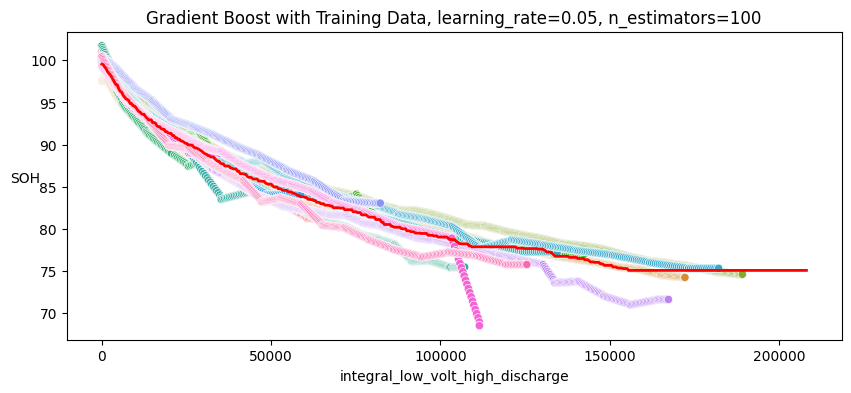

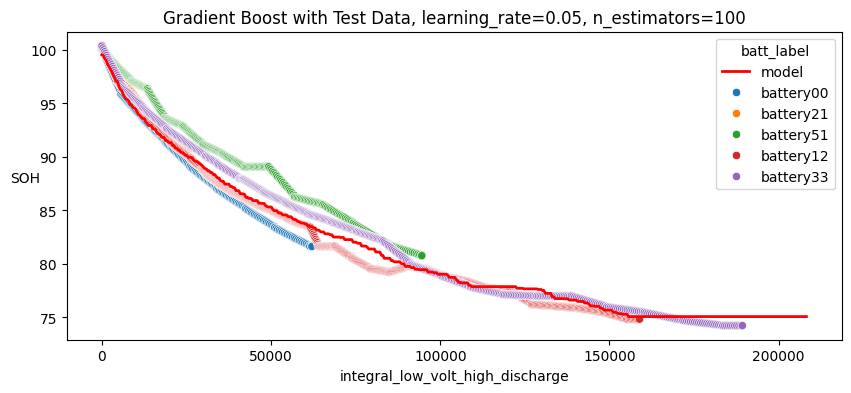

In [16]:
best_model = GradientBoostingRegressor(max_depth=2, n_estimators=100,
                        learning_rate=0.05, random_state=42)

X_train = np.array(train_df['integral_low_volt_high_discharge']).reshape(-1,1)
y_train = train_df['SOH']

best_model.fit(X_train, y_train)
plot_predictions(best_model, train_df, 'integral_low_volt_high_discharge', "SOH", "Gradient Boost with Training Data,")
plot_predictions(best_model, test_df, 'integral_low_volt_high_discharge', "SOH", "Gradient Boost with Test Data,", legend=True)

### Integral discharged squared 

In [17]:
train_features = ['integral_discharge_squared']
append_mae("Integral C Rate Squared Feature", complete_df, "SOH", train_features)

MAEs set nr. 0: [1.886287270369713, 1.5480543220162386, 1.5443080270065062, 1.5438914312762375]
MAEs set nr. 1: [2.1079927519262402, 1.57265813269143, 1.475752266322465, 1.4734911676610927]
MAEs set nr. 2: [1.8953177716010754, 1.4576362922743342, 1.37731379740806, 1.382332754220506]
MAEs set nr. 3: [2.0295549455961717, 1.3472351336615465, 1.1947782213120408, 1.1785308144068176]
********************Mean MAEs averaged over all test sets:***********************
Mean MAEs: [1.97978818 1.48139597 1.39803808 1.39456154]


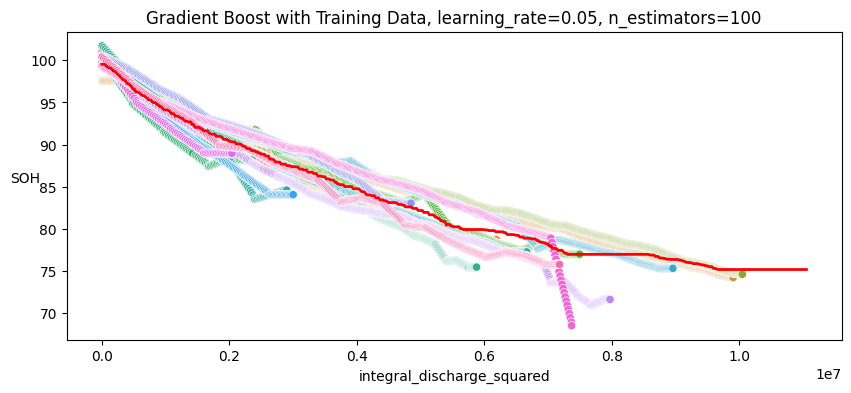

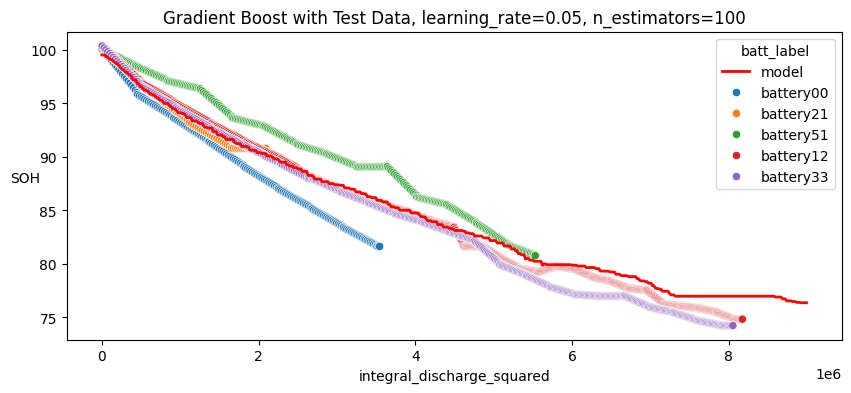

In [18]:
best_model = GradientBoostingRegressor(max_depth=2, n_estimators=100,
                        learning_rate=0.05, random_state=42)

X_train = np.array(train_df['integral_discharge_squared']).reshape(-1,1)
y_train = train_df['SOH']

best_model.fit(X_train, y_train)
plot_predictions(best_model, train_df, 'integral_discharge_squared', "SOH", "Gradient Boost with Training Data,")
plot_predictions(best_model, test_df, 'integral_discharge_squared', "SOH", "Gradient Boost with Test Data,", legend=True)

In [19]:
train_features = ['integral_discharge_squared_T']
append_mae("Integral C Rate Squared T Feature", complete_df, "SOH", train_features)

MAEs set nr. 0: [1.5136399562459344, 1.1475803012008587, 1.1657396016612707, 1.1742036030544474]
MAEs set nr. 1: [1.6371927397338535, 1.012541771790159, 0.9624957865794735, 0.962380250908976]
MAEs set nr. 2: [1.7493081881342742, 1.2460588601434748, 1.1800819131688498, 1.1769455708538707]
MAEs set nr. 3: [1.9622116217252634, 1.2329205470023776, 1.0484530533536236, 1.0279205571283634]
********************Mean MAEs averaged over all test sets:***********************
Mean MAEs: [1.71558813 1.15977537 1.08919259 1.0853625 ]


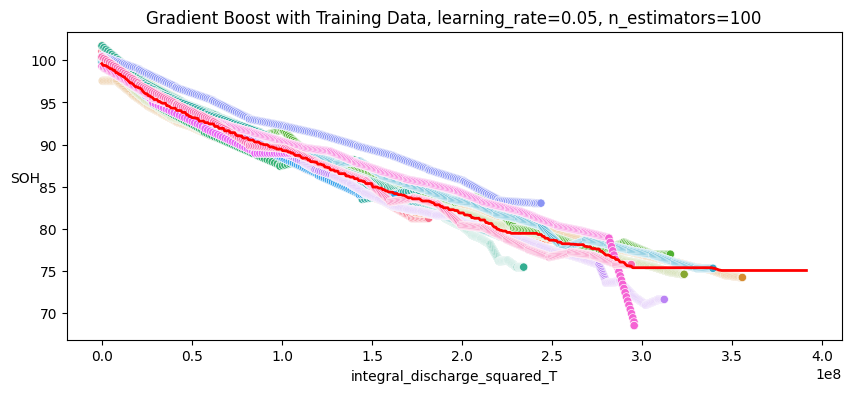

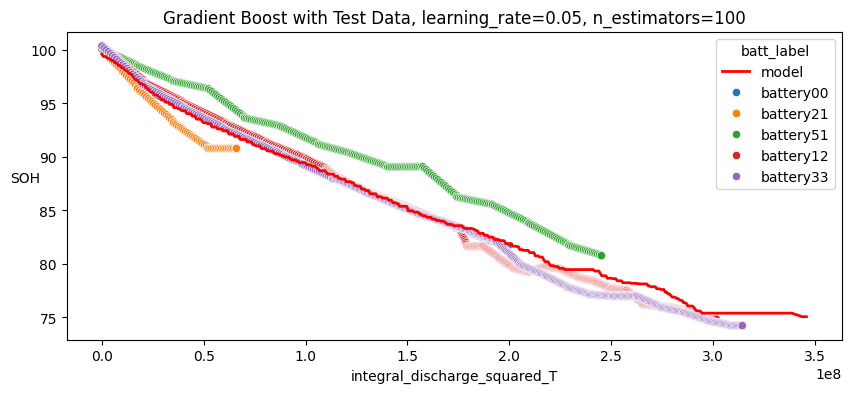

In [20]:
best_model = GradientBoostingRegressor(max_depth=2, n_estimators=100,
                        learning_rate=0.05, random_state=42)

X_train = np.array(train_df['integral_discharge_squared_T']).reshape(-1,1)
y_train = train_df['SOH']

best_model.fit(X_train, y_train)
plot_predictions(best_model, train_df, 'integral_discharge_squared_T', "SOH", "Gradient Boost with Training Data,")
plot_predictions(best_model, test_df, 'integral_discharge_squared_T', "SOH", "Gradient Boost with Test Data,", legend=True)

### Feature set with all integrals

In [21]:
train_features = ['integral_low_volt_high_discharge', 'integral_discharge_squared', 'integral_discharge_squared_T','integral_high_temp_high_discharge']
append_mae("All integral features", complete_df, "SOH", train_features)

MAEs set nr. 0: [1.4098805390163998, 1.0110530199853451, 1.023968811662757, 1.0291604211869516]
MAEs set nr. 1: [1.6505624184115428, 1.0023557944876011, 0.9014257929029313, 0.8903550514567335]
MAEs set nr. 2: [1.7036451711494034, 1.2561466058364918, 1.2124863819822231, 1.205883891344706]
MAEs set nr. 3: [1.9330053771796758, 1.1310941406083972, 0.9540572163452555, 0.9299800071339793]
************Mean Featue Importances averaged over all training sets:**************
                             Feature  Importance
0   integral_low_volt_high_discharge    0.497499
2       integral_discharge_squared_T    0.448713
1         integral_discharge_squared    0.037309
3  integral_high_temp_high_discharge    0.016478
********************Mean MAEs averaged over all test sets:***********************
Mean MAEs: [1.67427338 1.10016239 1.02298455 1.01384484]


## Feature-Set R_mOhm and C_rate_cycle_max

In [22]:
train_features = ['R_mOhm','C_rate_cycle_max']
append_mae("R_mOhm and C_rate_cycle_max Features", complete_df, "SOH", train_features)

MAEs set nr. 0: [3.4361099220992313, 2.9911514729602033, 2.8615300453539607, 2.855999976463675]
MAEs set nr. 1: [3.8859452340968925, 3.5723957852071946, 3.3731734245911915, 3.2985170880633605]
MAEs set nr. 2: [3.4661604516989977, 3.2471222951923258, 3.0748649103753776, 3.05316486069592]
MAEs set nr. 3: [3.3875884514252563, 2.886803404979211, 2.6382491741597227, 2.5521637353456668]
************Mean Featue Importances averaged over all training sets:**************
            Feature  Importance
0            R_mOhm    0.764763
1  C_rate_cycle_max    0.235237
********************Mean MAEs averaged over all test sets:***********************
Mean MAEs: [3.54395101 3.17436824 2.98695439 2.93996142]


## C Rate Histogram Feature Set

In [23]:
train_features = C_Rate_Hist_Features
append_mae("C Rate Histogram Features", complete_df, "SOH", train_features)

MAEs set nr. 0: [2.1815779398098307, 1.4985311157665528, 1.2312875959943521, 1.2228402313646147]
MAEs set nr. 1: [2.5217138424436145, 1.944958902358152, 1.7115422916953724, 1.6465084124308356]
MAEs set nr. 2: [2.0129585333502225, 1.4449232788698223, 1.102356185633674, 1.1158432962805993]
MAEs set nr. 3: [2.2550089471296, 1.5498643021700143, 1.2573608612503033, 1.1448318767284795]
************Mean Featue Importances averaged over all training sets:**************
            Feature  Importance
2    sec_C_rate_1_2    0.728043
0  sec_C_rate_0_0.5    0.138557
7    sec_C_rate_6_7    0.099271
6    sec_C_rate_5_6    0.012499
4    sec_C_rate_3_4    0.008173
8   sec_C_rate_gt_7    0.006840
5    sec_C_rate_4_5    0.006461
3    sec_C_rate_2_3    0.000157
1  sec_C_rate_0.5_1    0.000000
********************Mean MAEs averaged over all test sets:***********************
Mean MAEs: [2.24281482 1.6095694  1.32563673 1.28250595]


## T Histogramm Feature Set

In [24]:
train_features = Temp_Hist_Features
append_mae("Temperature Histogram Features", complete_df, "SOH", train_features)

MAEs set nr. 0: [2.5223553516987205, 1.9674963931946798, 2.0082092429308482, 2.0749469724174285]
MAEs set nr. 1: [2.5325306113807784, 1.977611071872326, 1.9023175398650538, 1.9479834585665654]
MAEs set nr. 2: [1.9422518416295496, 1.5920352487420475, 1.4490634020913227, 1.4345839331608496]
MAEs set nr. 3: [2.4098957228100604, 1.7721913912471203, 1.6719629618396048, 1.6245344780760511]
************Mean Featue Importances averaged over all training sets:**************
       Feature  Importance
1  sec_T_30_45    0.803717
3  sec_T_60_80    0.116725
2  sec_T_45_60    0.046599
0  sec_T_15_30    0.024967
4  sec_T_gt_80    0.007992
********************Mean MAEs averaged over all test sets:***********************
Mean MAEs: [2.35175838 1.82733353 1.75788829 1.77051221]


## Feature set t(T > X°C)

In [25]:
train_features = ["sec_T_over_45"]
append_mae("sec_T_over_45 Feature", complete_df, "SOH", train_features)

MAEs set nr. 0: [2.382100346395393, 2.2952416961137847, 2.4891083555832063, 2.5163717039443743]
MAEs set nr. 1: [1.6992377059228618, 1.2356412247513446, 1.1677206082798148, 1.16209205951109]
MAEs set nr. 2: [2.1051501286983876, 1.6534482850427086, 1.5591037898417706, 1.553546034583435]
MAEs set nr. 3: [2.242211673839151, 1.6877059624415083, 1.5687787436222775, 1.562900484286613]
********************Mean MAEs averaged over all test sets:***********************
Mean MAEs: [2.10717496 1.71800929 1.69617787 1.69872757]


In [26]:
train_features = ["sec_T_over_40"]
append_mae("sec_T_over_40 Feature", complete_df, "SOH", train_features)

MAEs set nr. 0: [2.4010470343797397, 2.214698604626444, 2.2816952615354906, 2.2839189184415125]
MAEs set nr. 1: [2.2058763655390266, 1.6780161747973992, 1.5748099719106867, 1.5676529399639103]
MAEs set nr. 2: [2.0589994534828597, 1.7182630769179914, 1.648986752959309, 1.6402237736071796]
MAEs set nr. 3: [2.3297103476715066, 1.7817096467638391, 1.686118712380621, 1.6796830058663372]
********************Mean MAEs averaged over all test sets:***********************
Mean MAEs: [2.2489083  1.84817188 1.79790267 1.79286966]


In [27]:
train_features = ["sec_T_over_50"]
append_mae("sec_T_over_50 Feature", complete_df, "SOH", train_features)

MAEs set nr. 0: [2.179301629599694, 2.1079851925758635, 2.2458728955613245, 2.262119712348385]
MAEs set nr. 1: [2.917059047971142, 2.6383654469033058, 2.6207275542237465, 2.6209323408121015]
MAEs set nr. 2: [2.37374986233902, 1.9443261691539746, 1.8615956030191905, 1.8547555615684408]
MAEs set nr. 3: [2.4773628200533255, 1.925338189912137, 1.7978783496814965, 1.7883858219644886]
********************Mean MAEs averaged over all test sets:***********************
Mean MAEs: [2.48686834 2.15400375 2.1315186  2.13154836]


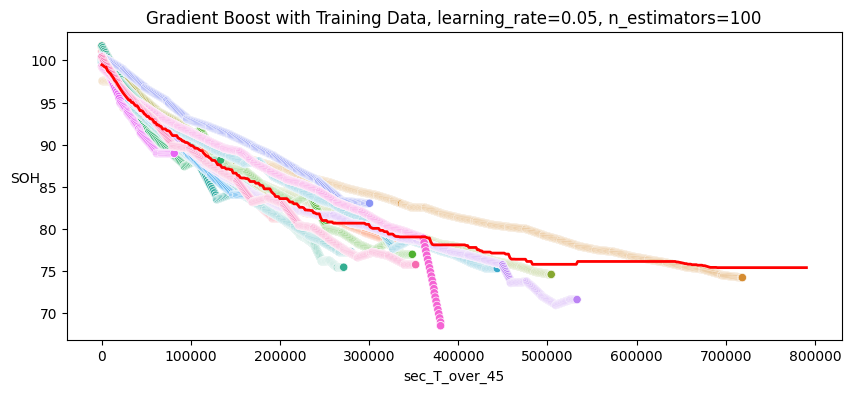

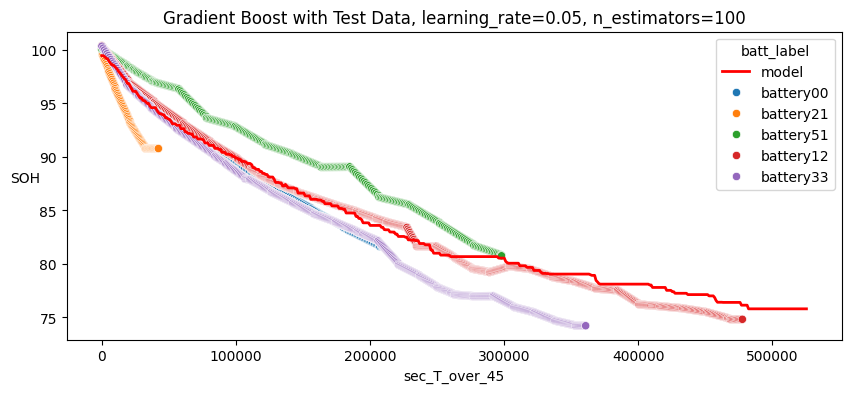

In [28]:
best_model = GradientBoostingRegressor(max_depth=2, n_estimators=100,
                        learning_rate=0.05, random_state=42)

X_train = np.array(train_df['sec_T_over_45']).reshape(-1,1)
y_train = train_df['SOH']

best_model.fit(X_train, y_train)
plot_predictions(best_model, train_df, 'sec_T_over_45', "SOH", "Gradient Boost with Training Data,")
plot_predictions(best_model, test_df, 'sec_T_over_45', "SOH", "Gradient Boost with Test Data,", legend=True)

## Power Feature Set ohne Q_norm

In [29]:
corr = complete_df.drop(['batt_label','isRefCycle'], axis=1).corr()
corr['SOH'].abs().sort_values(ascending=False)[:15]

SOH                                  1.000000
SOH(-30EFC)                          0.988710
integral_discharge_squared_T         0.973527
SOH(-60EFC)                          0.968699
Q_norm_at_3.6_V                      0.966412
Q_norm_at_3.7_V                      0.951180
integral_discharge_squared           0.946530
SOH(-90EFC)                          0.942965
integral_low_volt_high_discharge     0.933047
SOH(-120EFC)                         0.913529
Q_norm_at_3.8_V                      0.912133
integral_high_temp_high_discharge    0.906550
integral_low_volt_high_temp          0.904179
sec_T_over_45                        0.896958
sec_T_over_50                        0.890510
Name: SOH, dtype: float64

In [30]:
corr = complete_df.drop(['batt_label','isRefCycle'], axis=1).corr()
corr['integral_low_volt_high_discharge'].abs().sort_values()[:15]

integral_high_volt_high_temp    0.014553
T_cum_avg                       0.038199
sec_C_rate_2_3                  0.042215
T_cum_max                       0.048744
T_cycle_avg                     0.067246
sec_T_gt_80                     0.096440
T_cycle_min                     0.116572
sec_C_rate_gt_7                 0.147731
T_cum_min                       0.154780
C_rate_cum_max                  0.159423
T_cycle_max                     0.160965
sec_C_rate_6_7                  0.223454
R_mOhm                          0.236863
C_rate_cum_avg                  0.250641
C_rate_cycle_max                0.286678
Name: integral_low_volt_high_discharge, dtype: float64

In [31]:
train_features = ['integral_low_volt_high_discharge', 'integral_discharge_squared_T',\
                  'T_cum_avg', 'T_cum_max',\
                  'R_mOhm','C_rate_cycle_max'] + C_Rate_Hist_Features
append_mae("Power Features ohne Q_norm", complete_df, "SOH", train_features)

MAEs set nr. 0: [1.4175886020226907, 0.960849224096011, 0.8416007924761207, 0.8490499564553775]
MAEs set nr. 1: [1.6923743616108864, 0.9887723662513543, 0.9654716264741396, 0.9890034653478871]
MAEs set nr. 2: [1.7258651556353002, 1.0843988359635417, 1.176834046250383, 1.283913236431043]
MAEs set nr. 3: [1.9303366743855792, 1.1389726794844535, 0.9094087953340821, 0.8626471528993434]
************Mean Featue Importances averaged over all training sets:**************
                             Feature  Importance
0   integral_low_volt_high_discharge    0.482198
1       integral_discharge_squared_T    0.458219
8                     sec_C_rate_1_2    0.022781
6                   sec_C_rate_0_0.5    0.011306
13                    sec_C_rate_6_7    0.008750
4                             R_mOhm    0.004198
12                    sec_C_rate_5_6    0.003776
2                          T_cum_avg    0.003558
3                          T_cum_max    0.002462
10                    sec_C_rate_3_4    0.

## Q_norm and C rate Histogram

In [32]:
train_features = ['Q_norm_at_3.6_V', 'Q_norm_at_3.7_V','Q_norm_at_3.8_V', 'Q_norm_at_3.9_V'] + C_Rate_Hist_Features
append_mae("Q_norm and C Histogram Features", complete_df, "SOH", train_features)

MAEs set nr. 0: [1.5499269886977132, 0.9931657364942201, 0.96180220665122, 0.9594845640317885]
MAEs set nr. 1: [1.8094029282158934, 1.2569473142105876, 1.1446560285419203, 1.1523835028737281]
MAEs set nr. 2: [1.8914998879975404, 1.2913404497147345, 1.238742975016863, 1.282421371834483]
MAEs set nr. 3: [1.8413281231618766, 1.1089122332824253, 0.9619355182368025, 0.9193058097154111]
************Mean Featue Importances averaged over all training sets:**************
             Feature  Importance
0    Q_norm_at_3.6_V    0.751830
6     sec_C_rate_1_2    0.123665
4   sec_C_rate_0_0.5    0.057766
1    Q_norm_at_3.7_V    0.030848
11    sec_C_rate_6_7    0.019441
2    Q_norm_at_3.8_V    0.006148
10    sec_C_rate_5_6    0.004440
3    Q_norm_at_3.9_V    0.003075
8     sec_C_rate_3_4    0.001316
7     sec_C_rate_2_3    0.001058
9     sec_C_rate_4_5    0.000215
12   sec_C_rate_gt_7    0.000198
5   sec_C_rate_0.5_1    0.000000
********************Mean MAEs averaged over all test sets:*************

### Zusammenfassung Machine Learning SOH

#### Gradient Boost

In [33]:
all_mae_df = pd.DataFrame(all_mae)
all_mae_df

,Complete Feature Set,EFC Feature,EFC and C rate average Features,Q_norm_at_3.6_V Feature Set,Q_norm_at_3.6_V Feature when SOH < 95 %,Complete Q_norm Feature Set,Complete Q_norm Feature Set when SOH < 95,"Q_norm_at(3.8V, 3.9V) Feature Set",Complete Feature Set without Q_norm,Integral low volt high discharge Feature,...,Integral C Rate Squared T Feature,All integral features,R_mOhm and C_rate_cycle_max Features,C Rate Histogram Features,Temperature Histogram Features,sec_T_over_45 Feature,sec_T_over_40 Feature,sec_T_over_50 Feature,Power Features ohne Q_norm,Q_norm and C Histogram Features
MAE @ 10 Estimators,1.695934,2.530040,2.385268,1.767263,1.570548,1.782693,1.571372,2.262120,1.471838,1.698261,...,1.715588,1.674273,3.543951,2.242815,2.351758,2.107175,2.248908,2.486868,1.691541,1.773039
MAE @ 30 Estimators,1.140054,2.107915,1.795080,1.223464,1.135936,1.247380,1.136407,1.798218,0.764027,1.096347,...,1.159775,1.100162,3.174368,1.609569,1.827334,1.718009,1.848172,2.154004,1.043248,1.162591
MAE @ 100 Estimators,1.076324,2.038534,1.564145,1.163094,1.074545,1.131914,1.052324,1.708760,0.717809,1.021394,...,1.089193,1.022985,2.986954,1.325637,1.757888,1.696178,1.797903,2.131519,0.973329,1.076784
MAE @ 300 Estimators,1.073928,2.031696,1.554842,1.156852,1.070667,1.111234,1.033742,1.688824,0.727073,1.019486,...,1.085362,1.013845,2.939961,1.282506,1.770512,1.698728,1.792870,2.131548,0.996153,1.078399


## Lineare Regression mit integral_discharge_squared_T Feature

In [34]:
from sklearn.linear_model import LinearRegression

def train_linear_regression(data, target, feature_set):
    '''
    Berechnet lineare Regression
    '''

    y = data[target]
    
    if len(feature_set) == 1:
        X = np.array(data[feature_set[0]]).reshape(-1,1)
    else:
        X = data[feature_set]

    linReg = LinearRegression()
    linReg.fit(X, y)
    y_predict = linReg.predict(X)
    mae = mean_absolute_error(y, y_predict)

    coef = linReg.coef_
    intercept = linReg.intercept_
        
    return mae, coef, intercept, linReg



1.2812489098358193
[-7.63120313e-08]
97.4060913391683


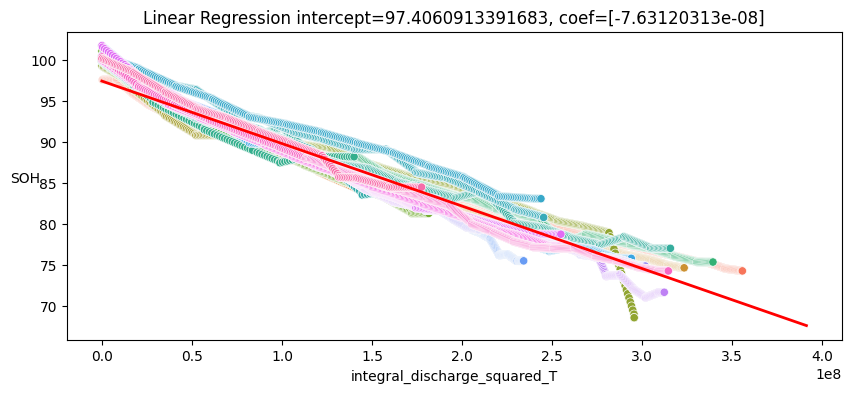

In [35]:
mae, coef, intercept, model = train_linear_regression(complete_df, "SOH", ["integral_discharge_squared_T"])
print(mae)
print(coef)
print(intercept)
plot_predictions(model, complete_df, 'integral_discharge_squared_T', "SOH", "Linear Regression", gradientBoost=False)

1.9488070333431
[-0.00014205]
94.2581852944459


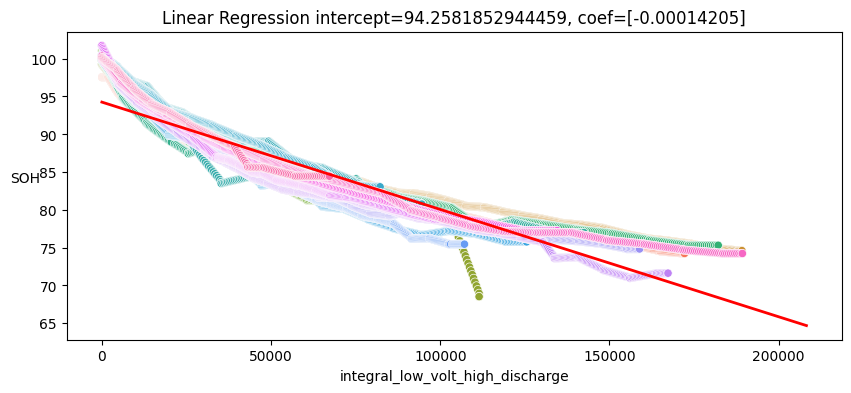

In [36]:
mae, coef, intercept, model = train_linear_regression(complete_df, "SOH", ["integral_low_volt_high_discharge"])
print(mae)
print(coef)
print(intercept)
plot_predictions(model, complete_df, 'integral_low_volt_high_discharge', "SOH", "Linear Regression", gradientBoost=False)

# Zusammenfassung Machine Learning SOH

* **Q_norm_at_3.6_V, integral_low_volt_high_discharge und integral_discharge_squared_T die wichtigsten einzelnen Features:**
    * **Q_norm_at_3.6_V**: Ladung die benötigt wird um Zelle von Vollladung (ca. 4,2V) auf Nennspannung (3,6V) zu entladen,
              normiert auf die nominale Kapazität. Im realen Betrieb nicht immer vorhanden. Als einzelnes Feature konnte mit Gradient
              Boost ein MAE von ca. 1,3 % erzielt werden. Mit allen Q(V) bis 3,6V sogar 1,0 %.
    * **integral_low_volt_high_discharge**: sum(max(3,1V-voltage, 0) * max(C_rate - 1C, 0) * delta_t). Gewichtetes Integral
      wenn Zellspannung unter 3,1V und Entladestrom über 1C. In realen Betrieb wahrscheinlich nicht das wichtigste Feature,
      da Batteriemanagementsystem (BMS) Entladestrom begrenzt wenn Batterieladung gering ist. Als einzelnes Feature konnte mit
      Gradient Boost ein MAE von ca. 1,3 % erzielt werden.
    * **integral_discharge_squared_T**: sum(I ** 2 * (10 + abs(T-20°C)) * delta_t). MAE 1,1 % wenn einziges Feature. Deckt Über- und
      Untertemperaturen ab. Im realen Betrieb wahrscheinlich das nützlichste Feature.
* **komplettes C Rate Histogramm ebenfalls gutes Feature:**
    * Mit kompletten C Rate Histogramm konnte mit Gradient Boost ein MAE von ca. 1,3 % erzielt werden.
* **Bei meisten Features sind 100 Estimators (bei max_depth = 2) beste Modellkomplexität bei Gradient Boost**
* **Bei reinen Temperaturfeatures sec_T_over_45 sinnvolles Feature**
    * **sec_T_over_45**: Sekunden bei der die Batterie eine Temperatur über 45 °C hat. Im vergleich zu Thresholds von 40 °C und 50 °C
      konnte hier der beste MAE erzielt werden (ca. 2,0 %).
    * Als Feature für den EU Battery Pass sinnvoll, da hier eine Angabe in Sekunden gefordert ist, bei der die Batterie in einem
      kritischen Zustand ist
    * Komplettes Temperatur Histogramm nicht sinnvoll, da hier keine höherer MAE als mit den einzelnen Feature sec_T_over_45 erzielt
      werden konnte
* **Mit kombinierten Features konnte der beste MAE von ca. 1,0 % erzielt werden.**
* **Bei realen Anwendungen kann eine Kombination aus mehreren Features je nach Anwendungsfall sinnvoll sein**
    * integral_discharge_squared_T Feature deckt gut normalen Betrieb ab
    * Je nach BMS-Strategie können ergänzende Features wie integral_low_volt_high_discharge hinzugefügt werden
    * Bei hoher Bandbreite von der C Rate kann ein C Rate Histogramm sinnvoll sein
    * Bei stark schwankender Umgebungstemperatur kann T_avg und T_max oder Sekunden über Temperatur X als zusätzliche Features sinnvoll sein
* **Als einzelnes universelles Feature kann sec_T_over_45 oder integral_discharge_squared_T sinnvoll sein**
    * **sec_T_over_45**: Sekunden bei der Temperatur über 45 °C, wird in der Praxis oft beim EU Battery Pass verwendet, MAE ca. 1,95 %
    * **integral_discharge_squared_T**: sum(I ** 2 * (10 + abs(T-20°C)) * delta_t), MAE ca. 1,1 % mit Gradient Boost, da das Feature gut linear
      zum SOH verläuft, kann auch mit linearer Regression ein guter MAE von ca. 1,3 % erreicht werden!